this code simulates a LED diode as source,
light diffract at primary lens at 220μm from diode, (through LED medium of epoxy)
then diffract at a secondary lens (through glass medium)

In [1]:
config_path = "results/LED_collimator1220/config.yaml"
import numpy as np; import matplotlib.pyplot as plt # type: ignore
from datetime import datetime
import src.RS as RS
import src.math_tool as mt
import src.img_tool as it
import src.load_config as lc
import src.utils as utils
from tqdm import tqdm
import src.ASM as ASM
import gc
%matplotlib widget
%load_ext autoreload
%autoreload 2
c, π = lc.load(config_path), np.pi
Axs2D, Ays2D = np.meshgrid(c.sim.xs, c.sim.ys, indexing='ij')
Nθs = 64
θ0s = np.linspace(0, 2*π, Nθs, endpoint=False, dtype=np.float32)
n_L = 1.5 # refractive index in LED casing (epoxy)

cannot load aperture file


1. Design of primary lens

In [2]:
Axy = np.zeros_like(Axs2D, dtype=complex)
# config the Aperture plane

#simulate wave from a point on LED diode propagate to pinhole, in medium of refractive index n_L (probably epoxy)
x_L_point = np.array([0])
y_L_point = np.array([0])
z_L_point = np.array([-1220]) # N_point # location of electron hole recombination
θ_L_point = np.array([0])
magnitude_L_point = np.array([1])
# Rayleigh Sommerfeld summation
λ = c.λ/n_L
k = c.k * n_L
r = mt.dist(Axs2D[:, :, None], Ays2D[:, :, None], z=0, x_c = x_L_point, y_c=y_L_point, z_c = z_L_point) # Nx, Ny, N_point
E_center_0 = (-1j/λ * np.exp(k*1j*r)*z_L_point/r**2)@(np.exp(1j*θ_L_point)*magnitude_L_point) # Nx, Ny

In [3]:
# #simulate wave from a point on LED diode propagate to pinhole, in medium of refractive index n_L (probably epoxy)
# x_L_point = np.array([0])
# y_L_point = np.array([0])
# z_L_point = np.array([-100]) # N_point # location of electron hole recombination
# θ_L_point = np.array([0])
# magnitude_L_point = np.array([1])
# # Rayleigh Sommerfeld summation
# n_L = 1.5
# λ = c.λ/n_L
# k = c.k * n_L
# r = mt.dist(Axs2D[:, :, None], Ays2D[:, :, None], z=0, x_c = x_L_point, y_c=y_L_point, z_c = z_L_point) # Nx, Ny, N_point
# E_center_target_0 = (-1j/λ * np.exp(k*1j*r)*z_L_point/r**2)@(np.exp(1j*θ_L_point)*magnitude_L_point) # Nx, Ny

In [4]:
E_center_target_0 = 1 # plane wave
E_relative_0 = E_center_0 / E_center_target_0
θ_aperture = np.angle(E_relative_0)
cos_θ_aperture_θ0s = np.cos(θ_aperture[..., None]-θ0s) # Nx, Ny, Nθs
# print(cos_θ_aperture_θ0s.shape)
edge = it.block_edge_mask(c.sim.Nx, c.sim.Ny, c.sim.Nx//2) # Nx, Ny # circle mask of Nx x Ny pixel with pixel radius
# apply constraint of 100μm diameter
aperture_design = (cos_θ_aperture_θ0s > 0) * ( edge[:, :, None] == True ) # set edge to block
# find best possible match over range of reference phase
#                  phase_similarity (Nx, Ny, Nθs)
cosine_similarity = (cos_θ_aperture_θ0s * aperture_design * np.abs(E_center_0)[:, :, None]).sum(axis=(0, 1)) # Nθs (range of reference phase)
idx_max = cosine_similarity.argmax()
idx_min = cosine_similarity.argmin()
print(f'min similarity phase / max similarity phase\n{cosine_similarity[idx_min] / cosine_similarity[idx_max]}')
import gc
del cos_θ_aperture_θ0s
lens = aperture_design[:, :, idx_max]
del aperture_design
gc.collect()

min similarity phase / max similarity phase
0.9727751850536562


54

In [5]:
print(lens.shape)

(300, 300)


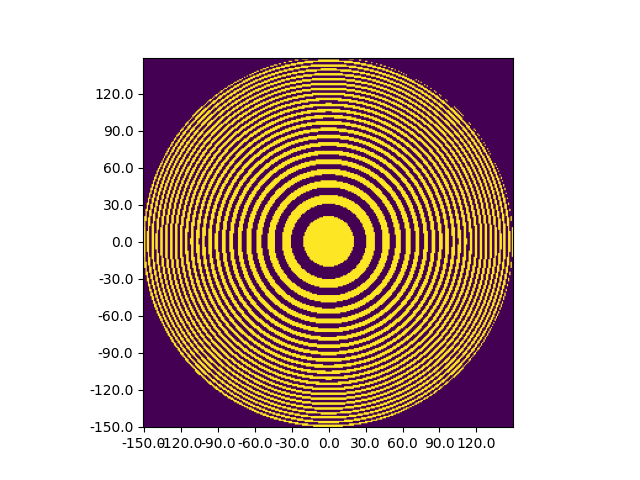

In [5]:
plt.imshow(lens.T);plt.gca().invert_yaxis()
plt.xticks(c.x_tick_idxs, c.xs[c.x_tick_idxs])
plt.yticks(c.y_tick_idxs, c.ys[c.y_tick_idxs])
plt.show()
name = 'LED_-1220μm_2_ooμm_λ620nm_300'
it.array_2_img(lens, f'{c.path.results}/{name}.bmp')

2. Simulation of light from a point on LED diode to propagate to desigend primary lens (E_test)

In [6]:
x_L_point = np.array([20])
y_L_point = np.array([0])
z_L_point = np.array([-1220]) # N_point # location of electron hole recombination
θ_L_point = np.array([0])
magnitude_L_point = np.array([1])
# Rayleigh Sommerfeld summation
n_L = 1.5
λ = c.λ/n_L
k = c.k * n_L
r = mt.dist(Axs2D[:, :, None], Ays2D[:, :, None], z=0, x_c = x_L_point, y_c=y_L_point, z_c = z_L_point) # Nx, Ny, N_point
E_test_0 = (-1j/λ * np.exp(k*1j*r)*z_L_point/r**2)@(np.exp(1j*θ_L_point)*magnitude_L_point) # Nx, Ny
E_test_0 *= edge # set edge to block
E_test_0_lens = E_test_0 * lens

3. find intensity distribution vs angle (E_test_0)
vs 
intensity distribution vs angle after lens (E_test_0_lens)

(300, 300)


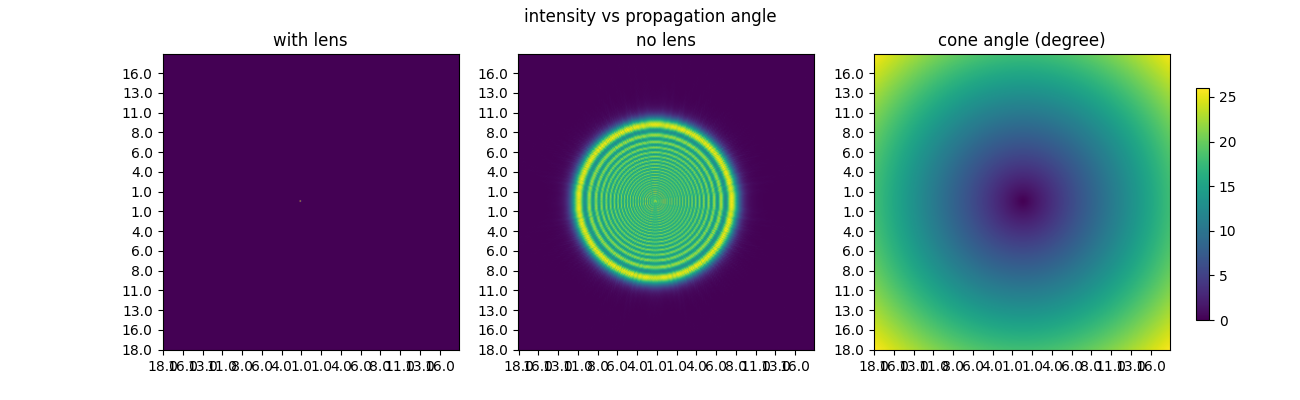

In [ ]:
intensity_dist_lens, kθ, xθ, yθ = ASM.Angular_intensity_dist(E_test_0_lens, c.sim.Lx, c.sim.Ly, λ=c.λ)
intensity_dist, _, _, _ = ASM.Angular_intensity_dist(E_test_0, c.sim.Lx, c.sim.Ly, λ=c.λ)

f_range = 300; Nx, Ny = intensity_dist.shape
x_angles = np.fft.fftshift(xθ)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range]
y_angles = np.fft.fftshift(yθ)[Ny // 2 - f_range: Ny // 2 + f_range, Ny // 2 - f_range: Ny // 2 + f_range]
x_angle_ticks = np.linspace(0, len(x_angles), len(x_angles)//60, endpoint=False, dtype=int)
y_angle_ticks = np.linspace(0, len(y_angles), len(y_angles)//60, endpoint=False, dtype=int)

print(intensity_dist.shape)
f_range = 600; Nx, Ny = intensity_dist_lens.shape
plt.clf()
layout = [[0, 1, 2]]
fig, ax = plt.subplot_mosaic(layout, figsize=(13,4))
plots = [np.fft.fftshift(intensity_dist_lens)[Nx // 2 - f_range: Nx // 2 + f_range, Ny // 2 - f_range: Ny // 2 + f_range], np.fft.fftshift(intensity_dist)[Nx // 2 - f_range: Nx // 2 + f_range, Ny // 2 - f_range: Ny // 2 + f_range], np.fft.fftshift(kθ.real)[Nx // 2 - f_range: Nx // 2 + f_range, Ny // 2 - f_range: Ny // 2 + f_range]]
title = ['with lens', 'no lens','cone angle (degree)']
angles = np.fft.fftshift(kθ)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range]
angle_ticks = np.linspace(0, len(angles), len(angles)//20, endpoint=False, dtype=int)
im = []

fig.suptitle("intensity vs propagation angle")
for i in range(len(plots)):
    im.append(ax[i].imshow(plots[i].T));ax[i].invert_yaxis()
    ax[i].set_title(title[i])
    ax[i].set_xticks(x_angle_ticks, np.round(x_angles[x_angle_ticks, 0].real).astype(int))
    ax[i].set_yticks(y_angle_ticks, np.round(y_angles[0, y_angle_ticks].real).astype(int))

cax = fig.add_axes([0.92, 0.2, 0.01, 0.58])
fig.colorbar(im[2], cax=cax)
plt.show()

number of sample point: [    0   221   885  2025  3577  5589  8037 10909 14249 18009 22149 26789
 31781 37193 43053 49277 55893 62893 70265 76011 80207 83447 85947 87783
 89039]


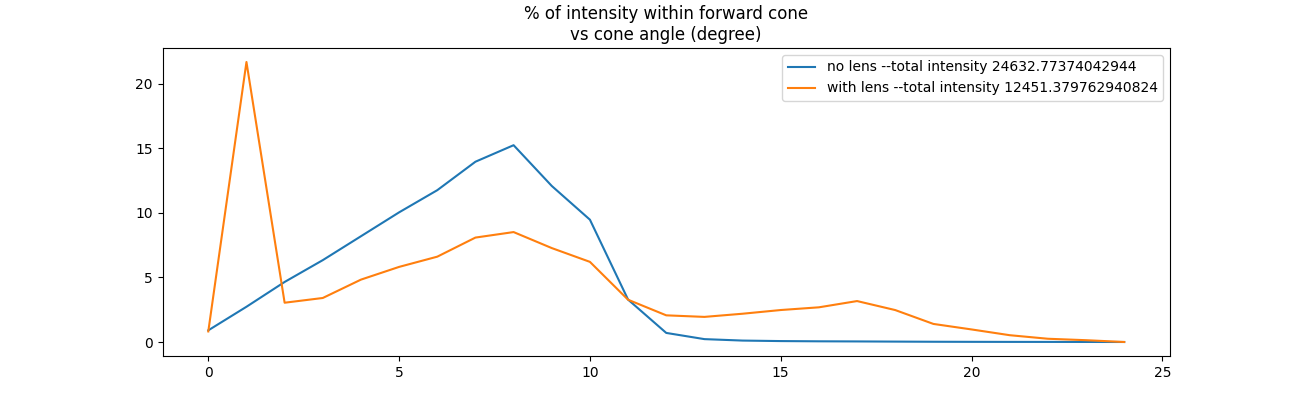

In [9]:
plt.clf()
cone_angle = np.linspace(0, 25, 25, endpoint=False)

total_intensity = intensity_dist.sum()

select_cone = (cone_angle < (kθ.real)[:, :, None]) * ((kθ.real)[:, :, None] < np.roll(cone_angle, -1)) # Nx, Ny, N_angle
#select_cone = ((kθ.real)[:, :, None] < np.roll(cone_angle, -1)) # Nx, Ny, N_angle
cone_intensity = (intensity_dist[:, :, None] * select_cone ).sum(axis=(0,1))

total_intensity_lens = intensity_dist_lens.sum()
cone_intensity_lens = (intensity_dist_lens[:, :, None] * select_cone).sum(axis=(0,1))
plt.plot(cone_angle, cone_intensity / total_intensity*100, label=f'no lens --total intensity {total_intensity}')
plt.plot(cone_angle, cone_intensity_lens / total_intensity_lens*100, label=f'with lens --total intensity {total_intensity_lens}')
plt.legend()
print(f'number of sample point: {((kθ.real)[:, :, None] < cone_angle).sum(axis=(0,1))}')
plt.title('% of intensity within forward cone\nvs cone angle (degree)')
plt.show()